# Seasonal Agriculture Performance Analysis

**VOIS AICTE Major Project – Data Analytics**

This notebook explores how agricultural performance (yield, cost, revenue, profit, water
usage and disease risk) changes across the three Indian cropping seasons — **Kharif,
Rabi and Zaid**. The goal is not to describe the whole dataset in general, but to answer
one focused question: *what actually changes from season to season, and why?*

**Workflow followed in this notebook:**
1. Data Loading & Inspection
2. Data Cleaning & Preparation
3. Feature Engineering
4. Exploratory Data Analysis (Seasonal Comparison)
5. Visualizations
6. Key Insights & Recommendations


## 1. Importing Libraries

Standard stack for data handling, stats and plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# A few display / plotting defaults so the notebook looks consistent throughout
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 150)


## 2. Loading the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset shape: 4000 rows, 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### 2.1 Quick Structural Check

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
# Basic statistical summary - helps spot obvious issues like negative values,
# unrealistic maxima, etc. before we go any further
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 3. Data Cleaning & Preparation

Before drawing any seasonal conclusions we need to make sure the data itself is
trustworthy. This section checks for missing values, duplicates and structural issues,
then fixes them in a way that doesn't distort the seasonal patterns we actually care
about.

In [5]:
# Which columns have missing values, and how many?
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [6]:
# Check for duplicate farm records
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Farm_IDs: {df['Farm_ID'].duplicated().sum()}")


Duplicate rows: 0
Duplicate Farm_IDs: 0


**Handling missing values:** `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`
each have a small number of missing entries (~1% of records). Since these values are
known to vary heavily by season, filling them with an overall column mean would blur
the very seasonal differences we're trying to study. Instead, each missing value is
filled with the **median of its own season**, which keeps the seasonal character of the
data intact.

In [7]:
# Impute season-wise instead of a blanket global fill
cols_to_fill = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_fill:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Confirm nothing was missed
print("Remaining missing values:\n", df[cols_to_fill].isnull().sum())


Remaining missing values:
 Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


**Checking for outliers:** Agricultural data commonly has a few extreme values
(e.g. a very large farm, or a season with a crop failure). We use the IQR method just
to flag how many extreme points exist per numeric column — we don't blindly drop them,
since a genuine crop failure or bumper harvest is exactly the kind of "unusual seasonal
pattern" the project brief asks us to look for.

In [8]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

numeric_cols = df.select_dtypes(include=np.number).columns
outlier_counts = df[numeric_cols].apply(count_outliers_iqr).sort_values(ascending=False)
outlier_counts[outlier_counts > 0]


Profit_INR                       404
Production_Tonnes                333
Water_Efficiency_t_per_1000m3    322
Yield_Tonnes_Ha                  302
Water_Used_m3                    276
Revenue_INR                      240
Potassium_kg_ha                   32
Sunlight_Hours_Day                26
Phosphorus_kg_ha                  16
Fertilizer_kg_ha                  15
Nitrogen_kg_ha                    10
Disease_Pest_Risk_pct             10
Pesticide_Litre_ha                 8
Humidity_pct                       6
Soil_Moisture_pct                  5
Avg_Temperature_C                  2
dtype: int64

The outlier counts are modest relative to the 4,000 records, so they are kept in
the dataset — they likely represent real extreme farms (e.g. Sugarcane farms with very
high yields, or a handful of loss-making seasons) rather than data entry errors.

In [9]:
# Standardise text categories - trim stray whitespace and fix capitalisation
# just in case (safe to run even if data is already clean)
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    df[col] = df[col].str.strip().str.title()

df[['State', 'District', 'Crop', 'Season', 'Irrigation_Method']].nunique()


State                 8
District             10
Crop                  8
Season                3
Irrigation_Method     4
dtype: int64

## 4. Feature Engineering

A couple of derived metrics make the seasonal economics much easier to interpret than
the raw cost/revenue figures alone.

In [10]:
# Profit margin as a % of revenue - easier to compare across farms of very
# different scale than raw rupee profit
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

# Cost incurred to produce one tonne of output
df['Cost_per_Tonne_INR'] = df['Total_Cost_INR'] / df['Production_Tonnes']

# Simple flag for loss-making farms, used later for a seasonal loss-rate comparison
df['Is_Loss_Making'] = df['Profit_INR'] < 0

df[['Profit_Margin_pct', 'Cost_per_Tonne_INR', 'Is_Loss_Making']].describe(include='all')


,Profit_Margin_pct,Cost_per_Tonne_INR,Is_Loss_Making
count,4000.000000,4000.000000,4000
unique,NaN,NaN,2
top,NaN,NaN,False
freq,NaN,NaN,2034
mean,-45.492178,55624.858332,NaN
std,158.085472,54260.608703,NaN
min,-1461.851219,568.357511,NaN
25%,-60.192762,23032.641975,NaN
50%,1.146236,37897.601738,NaN
75%,32.885876,64153.096089,NaN


## 5. Exploratory Data Analysis

### 5.1 Season Overview

Before comparing outcomes, it's worth seeing how the data itself is distributed across
seasons — Kharif, Rabi and Zaid are not represented equally in real farming calendars.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


/tmp/ipykernel_550/1821096857.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')


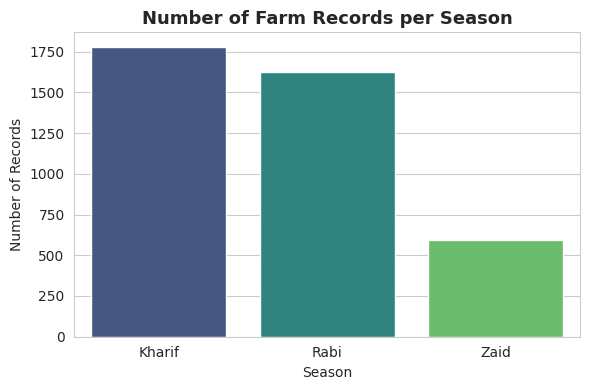

In [11]:
season_counts = df['Season'].value_counts()
print(season_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis')
plt.title('Number of Farm Records per Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


Kharif has the most records (~44%), followed by Rabi (~41%), with Zaid clearly the
smaller, shorter season (~15%). This is expected — Zaid is a short summer season grown
on limited land between the two main cropping seasons, so any Zaid-related patterns
should be read with that smaller sample size in mind.

### 5.2 Core Performance Metrics by Season

This is the heart of the analysis - how do yield, cost, revenue and profit actually
differ between the three seasons?

In [12]:
season_summary = df.groupby('Season')[[
    'Yield_Tonnes_Ha', 'Total_Cost_INR', 'Revenue_INR',
    'Profit_INR', 'Profit_Margin_pct'
]].mean().round(2)

season_summary


,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,,
Kharif,5.63,531804.41,710719.06,178914.65,-38.64
Rabi,5.04,513836.58,601526.05,87689.47,-44.27
Zaid,4.64,543976.73,519171.90,-24804.82,-69.35


/tmp/ipykernel_550/2562246333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean,


/tmp/ipykernel_550/2562246333.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean,
/tmp/ipykernel_550/2562246333.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Total_Cost_INR', estimator=np.mean,


/tmp/ipykernel_550/2562246333.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Revenue_INR', estimator=np.mean,


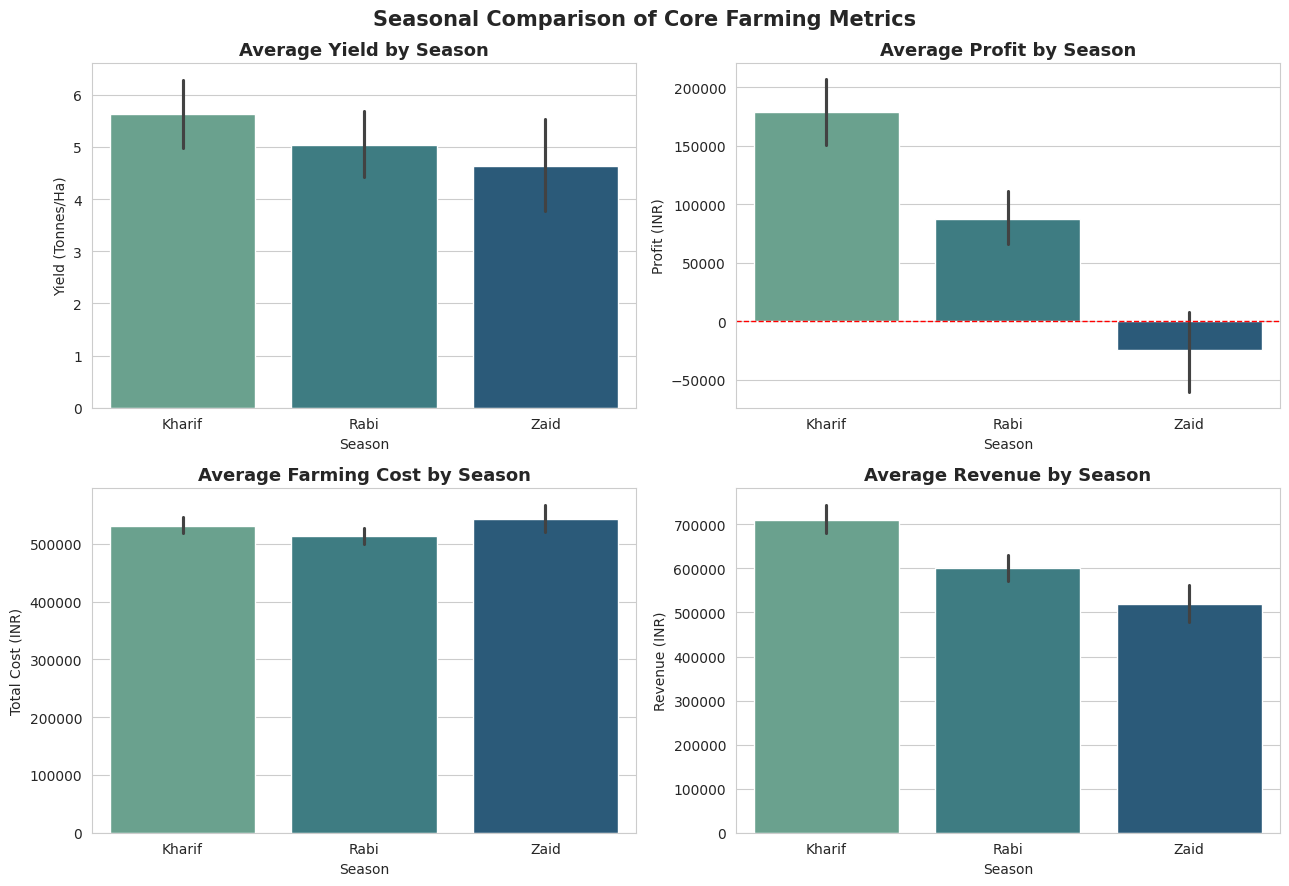

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='crest', ax=axes[0, 0])
axes[0, 0].set_title('Average Yield by Season')
axes[0, 0].set_ylabel('Yield (Tonnes/Ha)')

sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='crest', ax=axes[0, 1])
axes[0, 1].set_title('Average Profit by Season')
axes[0, 1].set_ylabel('Profit (INR)')
axes[0, 1].axhline(0, color='red', linewidth=1, linestyle='--')

sns.barplot(data=df, x='Season', y='Total_Cost_INR', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='crest', ax=axes[1, 0])
axes[1, 0].set_title('Average Farming Cost by Season')
axes[1, 0].set_ylabel('Total Cost (INR)')

sns.barplot(data=df, x='Season', y='Revenue_INR', estimator=np.mean,
            order=['Kharif', 'Rabi', 'Zaid'], palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('Average Revenue by Season')
axes[1, 1].set_ylabel('Revenue (INR)')

plt.suptitle('Seasonal Comparison of Core Farming Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Kharif consistently comes out ahead on both yield and profit, while
Zaid is the weakest season financially — average profit is actually *negative* in Zaid,
even though cost of farming stays roughly similar across all three seasons. That tells
us the problem isn't spending more in Zaid, it's earning less back from it.

Share of loss-making farms by season (%):
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss_Making, dtype: float64


/tmp/ipykernel_550/3251085789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_rate.index, y=loss_rate.values, palette='rocket')


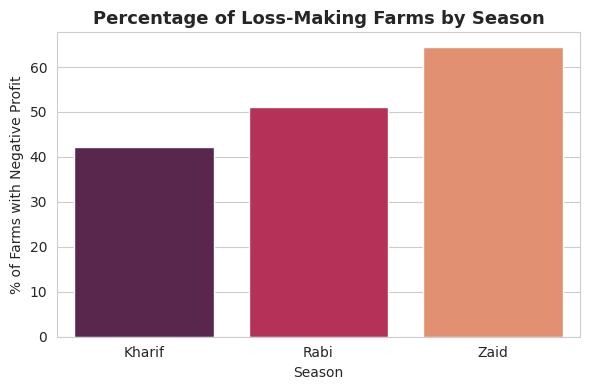

In [14]:
# How widespread are losses in each season? A mean can hide this, so we look
# at the share of loss-making farms directly.
loss_rate = df.groupby('Season')['Is_Loss_Making'].mean().mul(100).round(1)
loss_rate = loss_rate.reindex(['Kharif', 'Rabi', 'Zaid'])
print("Share of loss-making farms by season (%):")
print(loss_rate)

plt.figure(figsize=(6, 4))
sns.barplot(x=loss_rate.index, y=loss_rate.values, palette='rocket')
plt.title('Percentage of Loss-Making Farms by Season')
plt.ylabel('% of Farms with Negative Profit')
plt.tight_layout()
plt.show()


Nearly two-thirds of Zaid farms operate at a loss, compared to under half in
Kharif. Combined with the profit chart above, this is one of the clearest seasonal
findings in the dataset.

### 5.3 Environmental Conditions Across Seasons

Rainfall and temperature are the most obvious seasonal drivers - checking how they
differ helps explain *why* the performance gap above exists.

/tmp/ipykernel_550/2890196160.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=['Kharif', 'Rabi', 'Zaid'],
/tmp/ipykernel_550/2890196160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=['Kharif', 'Rabi', 'Zaid'],
/tmp/ipykernel_550/2890196160.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Humidity_pct', order=['Kharif', 'Rabi', 'Zaid'],


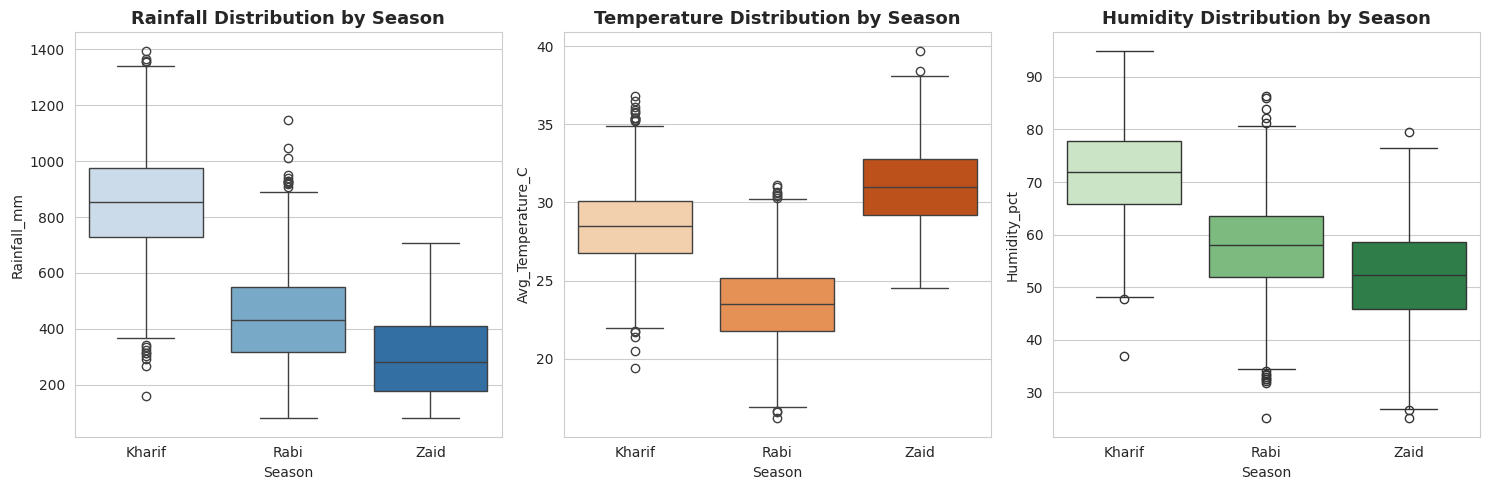

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=['Kharif', 'Rabi', 'Zaid'],
            palette='Blues', ax=axes[0])
axes[0].set_title('Rainfall Distribution by Season')

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C', order=['Kharif', 'Rabi', 'Zaid'],
            palette='Oranges', ax=axes[1])
axes[1].set_title('Temperature Distribution by Season')

sns.boxplot(data=df, x='Season', y='Humidity_pct', order=['Kharif', 'Rabi', 'Zaid'],
            palette='Greens', ax=axes[2])
axes[2].set_title('Humidity Distribution by Season')

plt.tight_layout()
plt.show()


Zaid is the hottest and driest of the three seasons (highest median temperature,
lowest rainfall) — which lines up with it being the summer season where crops rely
much more heavily on irrigation instead of natural rainfall. This is a plausible root
cause for its weaker profit performance, especially where irrigation is inefficient
(see Section 5.5).

### 5.4 Crop Performance Within Each Season

Averaging across all crops can hide a lot — some crops may only be viable in specific
seasons. This view breaks yield down by both crop and season together.

In [16]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season',
                                    values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


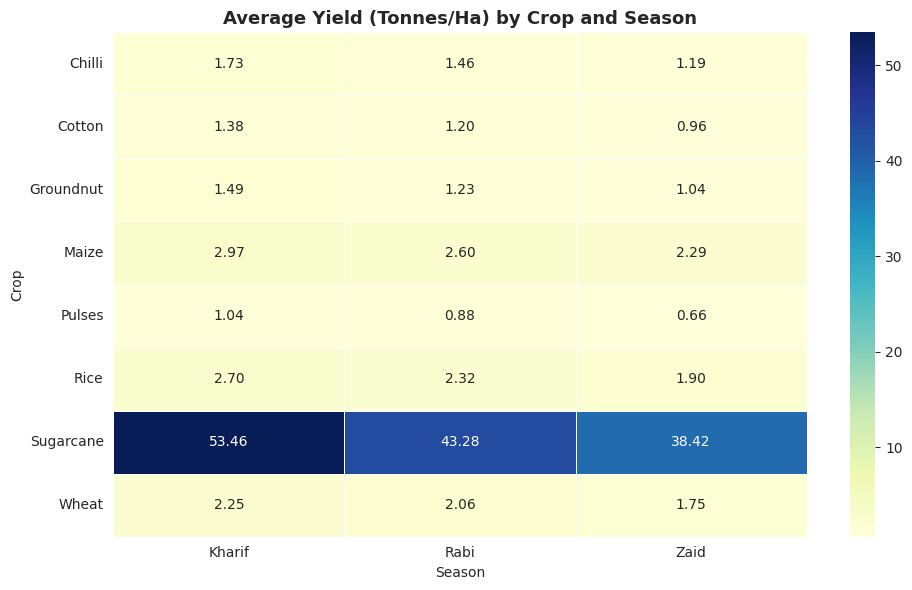

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Yield (Tonnes/Ha) by Crop and Season')
plt.tight_layout()
plt.show()


Sugarcane's yield figures are on a completely different scale to every other crop
(tens of tonnes/ha vs low single digits), which is expected agronomically - it's
included here for completeness, but it's worth analysing separately from the grain/
pulse crops so it doesn't visually dominate every comparison.

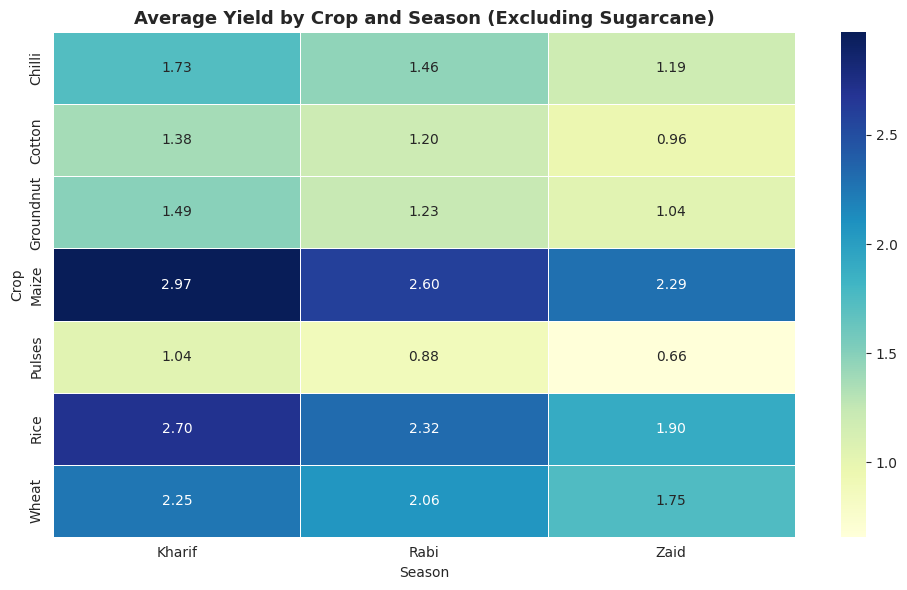

In [18]:
# Re-plot excluding Sugarcane so the remaining crops are actually comparable
plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield.drop('Sugarcane'), annot=True, fmt='.2f',
            cmap='YlGnBu', linewidths=0.5)
plt.title('Average Yield by Crop and Season (Excluding Sugarcane)')
plt.tight_layout()
plt.show()


With Sugarcane set aside, Maize and Rice consistently give the best yields in
Kharif, while Wheat performs best in Rabi - which matches real-world sowing calendars
where wheat is a classic winter (Rabi) crop and rice/maize are monsoon (Kharif) crops.
Pulses have the weakest yield in every season they're grown in.

### 5.5 Water Usage & Irrigation Efficiency

Since Zaid relies most on irrigation, it's worth checking whether *how* farms irrigate
(not just how much water they use) makes a measurable difference to output.

Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


/tmp/ipykernel_550/2985930718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=irrigation_eff.index, y=irrigation_eff.values, palette='mako')


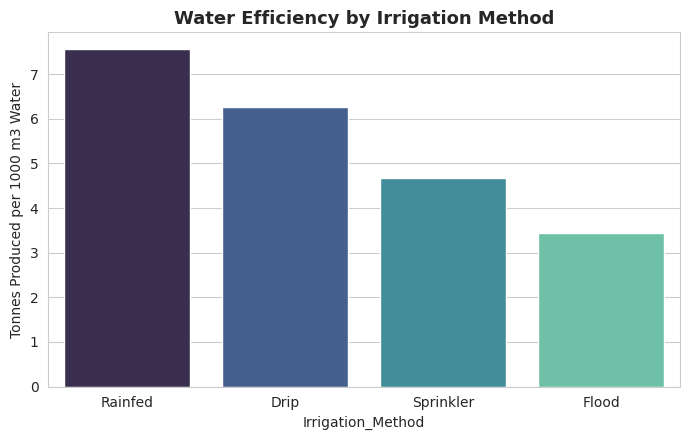

In [19]:
irrigation_eff = df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean() \
                    .sort_values(ascending=False).round(2)
print(irrigation_eff)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=irrigation_eff.index, y=irrigation_eff.values, palette='mako')
plt.title('Water Efficiency by Irrigation Method')
plt.ylabel('Tonnes Produced per 1000 m3 Water')
plt.tight_layout()
plt.show()


In [20]:
# Does irrigation method usage differ by season? e.g. is Zaid over-reliant
# on a less efficient method?
irrigation_by_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').mul(100).round(1)
irrigation_by_season = irrigation_by_season.reindex(['Kharif', 'Rabi', 'Zaid'])
irrigation_by_season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


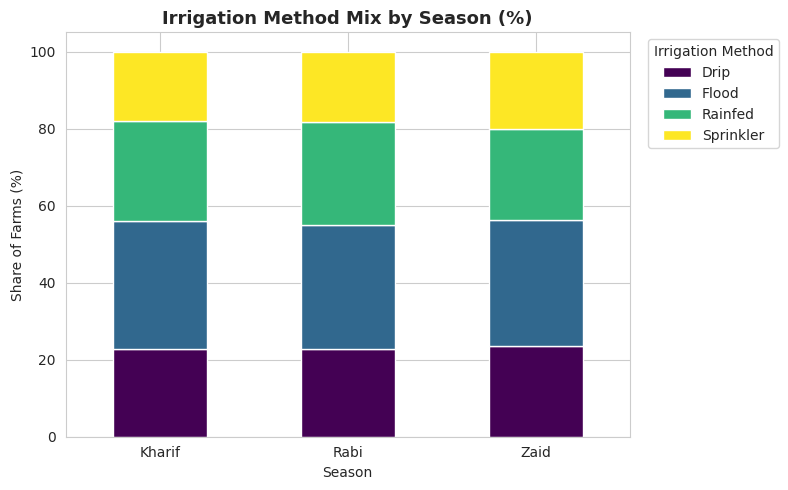

In [21]:
irrigation_by_season.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Irrigation Method Mix by Season (%)')
plt.ylabel('Share of Farms (%)')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Rainfed and Drip irrigation are the most water-efficient methods, while Flood
irrigation lags well behind. If Zaid farms lean more heavily on Flood irrigation while
also facing the least rainfall of the three seasons, that combination directly
explains part of the profit gap seen earlier.

### 5.6 Disease & Pest Risk by Season

/tmp/ipykernel_550/2746376826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct',


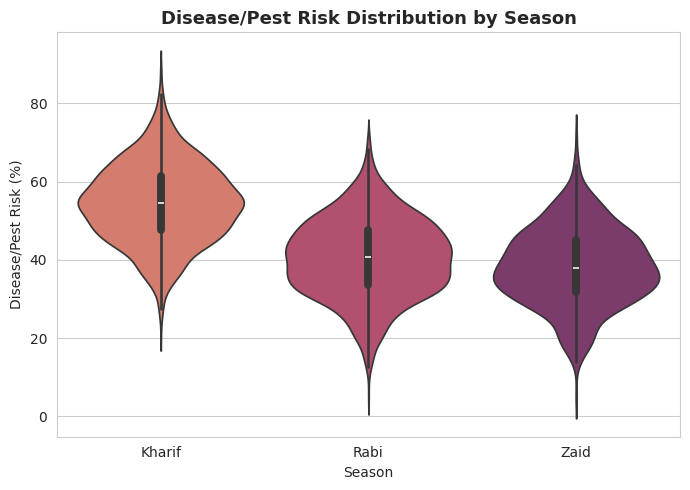

In [22]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct',
                order=['Kharif', 'Rabi', 'Zaid'], palette='flare')
plt.title('Disease/Pest Risk Distribution by Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()


Kharif shows the highest disease/pest risk on average, and the widest spread -
consistent with the higher humidity and rainfall of the monsoon season creating more
favourable conditions for pests and crop disease. Rabi and Zaid are comparatively
lower-risk, drier seasons.

### 5.7 What Actually Drives Yield?

A correlation heatmap across the key numeric variables helps identify which factors
move together with yield, rather than relying on assumptions.

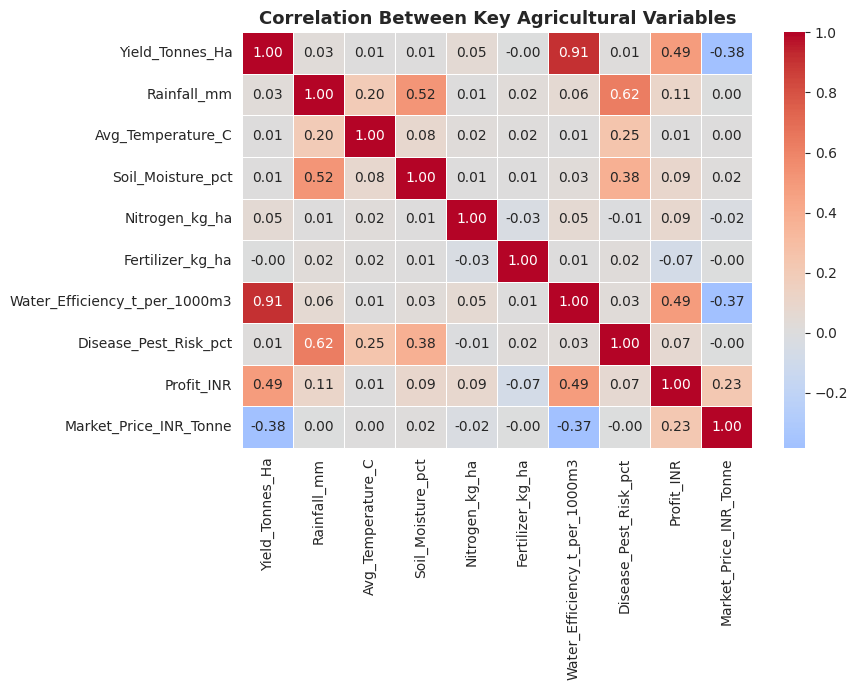

In [23]:
key_cols = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct',
            'Nitrogen_kg_ha', 'Fertilizer_kg_ha', 'Water_Efficiency_t_per_1000m3',
            'Disease_Pest_Risk_pct', 'Profit_INR', 'Market_Price_INR_Tonne']

corr_matrix = df[key_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Between Key Agricultural Variables')
plt.tight_layout()
plt.show()


**Observation:** `Water_Efficiency_t_per_1000m3` shows by far the strongest positive
relationship with yield of all the factors tested — much stronger than fertiliser,
nitrogen or rainfall individually. Interestingly, `Market_Price_INR_Tonne` is *negatively*
correlated with yield, which is a classic supply-and-demand signal: crops that are
produced in bulk (high yield) tend to fetch a lower price per tonne, and vice versa.
This is worth calling out explicitly since it isn't the intuitive answer.

### 5.8 Regional (State-Wise) View

Finally, checking whether the seasonal pattern found above holds consistently across
regions, or whether it's driven by a handful of states.

/tmp/ipykernel_550/2886311184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette='crest')


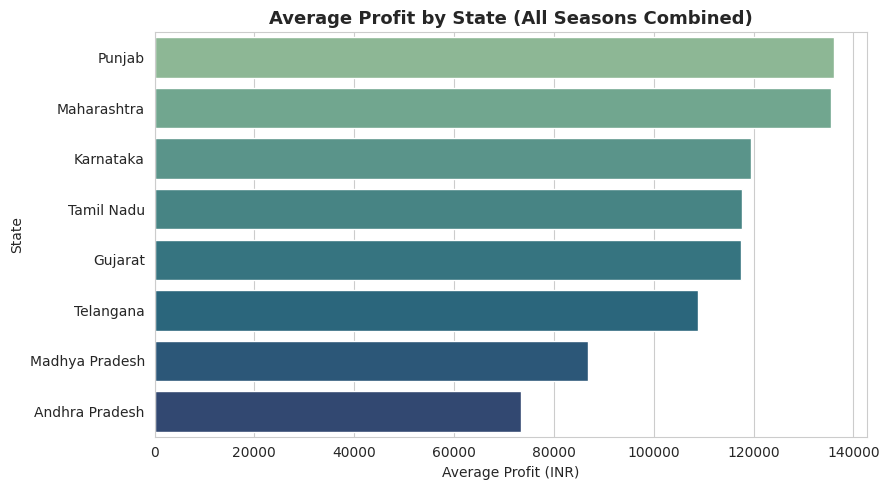

In [24]:
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).round(0)

plt.figure(figsize=(9, 5))
sns.barplot(x=state_profit.values, y=state_profit.index, palette='crest')
plt.title('Average Profit by State (All Seasons Combined)')
plt.xlabel('Average Profit (INR)')
plt.tight_layout()
plt.show()


In [25]:
# Does the Kharif > Rabi > Zaid profit ranking hold within every state too?
state_season_profit = df.pivot_table(index='State', columns='Season',
                                      values='Profit_INR', aggfunc='mean').round(0)
state_season_profit = state_season_profit[['Kharif', 'Rabi', 'Zaid']]
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


Punjab and Maharashtra post the highest overall average profit, while Andhra
Pradesh is lowest. Checking the season-by-state table above, the broad pattern of
Kharif performing best and Zaid performing worst holds true in most states - which
increases confidence that this is a genuine seasonal effect and not just a quirk of
one or two regions.

## 6. Statistical Significance Check

Before treating the seasonal profit gap as a solid conclusion, a quick one-way ANOVA
test confirms whether the difference in profit across the three seasons is
statistically significant, rather than something that could plausibly occur by chance.

In [26]:
kharif_profit = df.loc[df['Season'] == 'Kharif', 'Profit_INR']
rabi_profit   = df.loc[df['Season'] == 'Rabi', 'Profit_INR']
zaid_profit   = df.loc[df['Season'] == 'Zaid', 'Profit_INR']

f_stat, p_value = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The difference in profit across seasons is statistically significant.")
else:
    print("Result: No statistically significant difference found across seasons.")


F-statistic: 34.29
P-value: 0.000000
Result: The difference in profit across seasons is statistically significant.


## 7. Key Insights & Recommendations

**Key Insights**
1. **Kharif is the strongest season overall** - highest average yield (~5.6 t/ha) and
   the only season with a clearly positive average profit (~₹1.79 lakh/farm).
2. **Zaid is the weakest season financially** - average profit is *negative*, and
   nearly two-thirds of Zaid farms operate at a loss, despite similar farming costs to
   the other seasons. The problem is low output/revenue, not overspending.
3. **Zaid is also the hottest and driest season**, relying more on irrigation than
   natural rainfall — and water efficiency is the single strongest driver of yield in
   the dataset, stronger than fertiliser or nitrogen use.
4. **Crop choice matters by season**: Rice and Maize perform best in Kharif, Wheat
   performs best in Rabi, and Pulses are the weakest yielding crop across all seasons.
5. **Disease/pest risk peaks in Kharif**, consistent with monsoon humidity, even
   though Kharif is also the most profitable season - suggesting profitability is not
   being eroded by disease risk at current levels, but could be at higher risk levels.
6. **Market price moves inversely with yield**, a classic supply effect - high-yield
   seasons/crops earn less per tonne, which partly offsets the benefit of higher output.
7. The Kharif > Rabi > Zaid profitability pattern **holds across most states**, and an
   ANOVA test confirms the seasonal profit difference is statistically significant -
   this is a genuine seasonal effect, not noise or a regional artifact.

**Recommendations**
- Prioritise **drip/rainfed irrigation over flood irrigation** in Zaid, where water
  scarcity is the biggest constraint on yield.
- Re-evaluate crop selection in Zaid - the season may be better suited to
  drought-tolerant crops than the current mix.
- Since disease/pest risk is highest in Kharif, targeted pest-management support in
  that season could protect its already-strong margins from erosion.
- Given the inverse price-yield relationship, farmers in high-yield seasons/regions may
  benefit from better market access or staggered selling rather than assuming higher
  yield automatically means higher income.
